In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
#define state
class BMIState(TypedDict):
    weight:float
    height:float
    bmi:float
def calculateBmi(state:BMIState):
    weight = state['weight']
    height = state['height']
    state['bmi']= weight
graph=StateGraph(BMIState)
#add nodes to your graph
graph.add_node('calculateBmi',calculateBmi)
graph.add_edge(START,'calculateBmi')
graph.add_edge('calculateBmi',END)
#compile graph
workflow = graph.compile()
final_state= workflow.invoke({'weight':80,'height':1.74})


In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
class BmiState(TypedDict):
    height :float
    weight: float
    bmi:float
    category:str
def bmicalculate(state:BmiState) ->BmiState:
    height=state["height"]
    weight=state["weight"]
    state["bmi"]=(height)//(weight**2)
    return state
def bmiCategeory(state:BmiState)->BmiState:
    bmi=state["bmi"]
    if(bmi>20):
        state['category']= "good"
    else:
        state['category']="bad"
    return state
graph=StateGraph(BmiState)
graph.add_node('bmiCalculate',bmicalculate)
graph.add_node('bmiCategeory',bmiCategeory)
graph.add_edge(START,'bmiCalculate')
graph.add_edge('bmiCalculate','bmiCategeory')
graph.add_edge('bmiCategeory',END)

hhh=graph.compile()
hhh.invoke({"height":1.6,"weight":56})


{'height': 1.6, 'weight': 56, 'bmi': 0.0, 'category': 'bad'}

In [6]:
from langgraph.graph import StateGraph
from typing import TypedDict
class StateCalc(TypedDict):
    a:int
    b:int
    c:float
def summ(state:StateCalc)->StateCalc:
    a=state['a']
    b=state['b']
    state['c']=a+b
    return state
graph=StateGraph(StateCalc)
graph.add_node("summ",summ)
graph.add_edge(START,'summ')
graph.add_edge('summ',END)
jj=graph.compile()
jj.invoke({'a':6,'b':9})


{'a': 6, 'b': 9, 'c': 15}

In [7]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
load_dotenv()
class llmState(TypedDict):
    question:str
    answer:str
def llmqa(state:llmState)->llmState:
    llm= ChatGroq(model = "meta-llama/llama-4-scout-17b-16e-instruct")
    question=state['question']
    state['answer']=llm.invoke(question).content
    return state
graph = StateGraph(llmState)
graph.add_node("llmqa",llmqa)
graph.add_edge(START,'llmqa')
graph.add_edge('llmqa',END)

hh=graph.compile()
hh.invoke({'question':'Hi'})
hh.invoke({'question':'tell something'})

{'question': 'tell something',
 'answer': 'The shortest war in history was between Britain and Zanzibar on August 27, 1896, and lasted only 38 minutes. \n\nWould you like to hear more?'}

In [8]:
#prompt chaining
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
load_dotenv()
llm=ChatGroq(model= "meta-llama/llama-4-scout-17b-16e-instruct")
class promptChain(TypedDict):
    title:str
    outline:str
    content:str
def generateOutline(state:promptChain)->promptChain:
    title=state['title']
    prompt= f'generate the outline for a blog on the topic {title}'
    state['outline']=llm.invoke(prompt).content
    return state

def generateContent(state:promptChain)->promptChain:
    title=state['title']
    outline=state['outline']
    prompt= f'generate the context of the topic {title} as per {outline}'
    state['content']=llm.invoke(prompt).content
    return state

graph=StateGraph(promptChain)
graph.add_node('generateOutline',generateOutline)
graph.add_node('generateContext',generateContent)
graph.add_edge(START,'generateOutline')
graph.add_edge('generateOutline','generateContext')
graph.add_edge('generateContext',END)
model=graph.compile()
model.invoke({'title':'pochacco'})

{'title': 'pochacco',
 'outline': "Here is a suggested outline for a blog on the topic of Pochacco:\n\n**Title:** The Adventures of Pochacco: A Beloved Character from Japan\n\n**I. Introduction**\n\n* Brief overview of Pochacco and his popularity in Japan\n* Explanation of the blog post's purpose: to explore the world of Pochacco and his enduring appeal\n\n**II. Who is Pochacco?**\n\n* Background information on Pochacco's creation and debut\n* Description of Pochacco's character: a curious, adventurous dog with a distinctive appearance\n* Overview of Pochacco's personality traits and characteristics\n\n**III. Pochacco's World: Sanrio and Beyond**\n\n* Introduction to Sanrio, the company behind Pochacco's creation\n* Discussion of Pochacco's relationships with other Sanrio characters (e.g. Hello Kitty, My Melody)\n* Exploration of Pochacco's appearances in various media, such as anime, manga, and merchandise\n\n**IV. Pochacco's Appeal: Why We Love This Lovable Dog**\n\n* Analysis of Poc

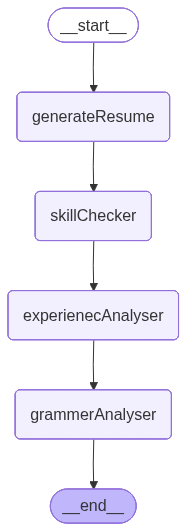

In [9]:
#parlell workflow in langgraph
from langgraph.graph import StateGraph, START , END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
llm=ChatGroq(model= 'meta-llama/llama-4-scout-17b-16e-instruct')
class mail():
    resume:str
    name:str
    skill_check:str
    experience_analyser:str
    re_resume:str
    output:str

def generateResume(state:mail)->mail:
    name= state['name']
    state['resume']=llm.invoke(f"create a resume of {name} who is 4 years experienced in nxp semiconductors working in euicc development").content
def skillChecker(state:mail)->mail:
    resume =state['resume']
    state['skill_check']=llm.invoke(f"check the skills of person in {resume} and list them out")
    return state
def experienecAnalyser(state:mail)->mail:
    resume =state['resume']
    state['experience_analyser']=llm.invoke(f"check the experience of of person in {resume} and list it out")
    return state
def grammerAnalyser(state:mail)->mail:
     resume =state['resume']
     state['re_resume']=llm.invoke(f"check the grammer in resume{resume} and rewrite it properly")
     return state

graph=StateGraph(mail)
graph.add_node('generateResume',generateResume)
graph.add_node('skillChecker',skillChecker)
graph.add_node('experienecAnalyser',experienecAnalyser)
graph.add_node('grammerAnalyser',grammerAnalyser)
graph.add_edge(START,'generateResume')
graph.add_edge('generateResume','skillChecker')
graph.add_edge('skillChecker','experienecAnalyser')
graph.add_edge('experienecAnalyser','grammerAnalyser')
graph.add_edge('grammerAnalyser',END)
graph.compile()


In [10]:
#parlell workflow in langgraph
from langgraph.graph import StateGraph, START , END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()
llm=ChatGroq(model= 'meta-llama/llama-4-scout-17b-16e-instruct')
class mail(TypedDict):
    resume:str
    name:str
    skill_check:str
    experience_analyser:str
    re_resume:str
    output:str

def generateResume(state:mail):
    name= state['name']
    return {'resume':llm.invoke(f"create a resume of {name} who is 4 years experienced in nxp semiconductors working in euicc development").content}
def skillChecker(state:mail)->mail:
    resume =state['resume']
    return {'skill_check':llm.invoke(f"check the skills of person in {resume} and list them out").content}
def experienecAnalyser(state:mail):
    resume =state['resume']

    return {'experience_analyser':llm.invoke(f"check the experience of of person in {resume} and list it out").content}
def grammerAnalyser(state:mail):
     resume =state['resume']
     return {'re_resume':llm.invoke(f"check the grammer in resume{resume} and rewrite it properly").content}

graph=StateGraph(mail)
graph.add_node('generateResume',generateResume)
graph.add_node('skillChecker',skillChecker)
graph.add_node('experienecAnalyser',experienecAnalyser)
graph.add_node('grammerAnalyser',grammerAnalyser)
graph.add_edge(START,'generateResume')
graph.add_edge('generateResume','skillChecker')
graph.add_edge('generateResume','experienecAnalyser')
graph.add_edge('generateResume','grammerAnalyser')
graph.add_edge('skillChecker',END)
graph.add_edge('experienecAnalyser',END)
graph.add_edge('grammerAnalyser',END)
workflow=graph.compile()
workflow.invoke({'name':'keerthi'})

{'resume': "Here's a sample resume for Keerthi with 4 years of experience in NXP Semiconductors working in eUICC development:\n\n**Keerthi**\n**Contact Information:**\n\n* Phone: +91-XXXXXXX\n* Email: [keerthi@email.com](mailto:keerthi@email.com)\n* LinkedIn: linkedin.com/in/keerthixxxx\n\n**Summary:**\nHighly motivated and experienced engineer with 4 years of experience in NXP Semiconductors, specializing in eUICC (embedded Universal Integrated Circuit Card) development. Proven track record of delivering high-quality projects and contributing to the development of innovative solutions. Strong knowledge of embedded systems, firmware development, and industry-standard protocols.\n\n**Professional Experience:**\n\n**eUICC Development Engineer, NXP Semiconductors** (2018 - Present)\n\n* Designed, developed, and tested eUICC solutions for various industries, including automotive, industrial, and consumer electronics\n* Worked on eUICC firmware development, including implementation of indus

In [11]:
jj=workflow.invoke({'name':'keerthi'})

In [12]:
jj['skill_check']

"Based on the provided resume, here are the skills of Keerthi:\n\n**Technical Skills:**\n\n1. **Programming languages:**\n\t* C\n\t* C++\n\t* Python\n2. **Operating Systems:**\n\t* Linux\n\t* Windows\n3. **Development frameworks:**\n\t* NXP's eUICC development framework\n4. **Familiarity with:**\n\t* Java Card\n\t* GlobalPlatform\n\t* ETSI standards\n5. **Domain expertise:**\n\t* Embedded systems\n\t* Secure elements\n\t* Cryptographic concepts\n\t* eUICC (embedded Universal Integrated Circuit Card) development\n\n**Soft Skills:**\n\n1. **Communication:** Collaborated with cross-functional teams and customers to understand their requirements and provide technical support.\n2. **Problem-solving:** Identified and mitigated potential security vulnerabilities in eUICC products.\n3. **Project management:** Delivered high-quality projects on time, with a focus on efficiency and process optimization.\n4. **Teamwork:** Worked with customers and internal teams to develop and deploy eUICC soluti